<a href="https://colab.research.google.com/github/sankeerthanagangam/Briday-Reminder/blob/main/Another_copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mdsultanulislamovi/sleep-disorder-diagnosis-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: G sankeerthana
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mdsultanulislamovi/sleep-disorder-diagnosis-dataset


100%|██████████| 2.54k/2.54k [00:00<00:00, 2.42MB/s]

In [ ]:
import pandas as pd
data = pd.read_csv("/content/sleep-disorder-diagnosis-dataset/Sleep_health_and_lifestyle_dataset.csv")

In [ ]:
data.head()


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## Address potential overfitting/underfitting

### Subtask:
Analyze the training and validation performance to identify and address overfitting or underfitting.

**Reasoning**:
Analyze the training history of the models (specifically the neural network, as it provides history) to identify potential overfitting or underfitting by visualizing the loss and accuracy curves.

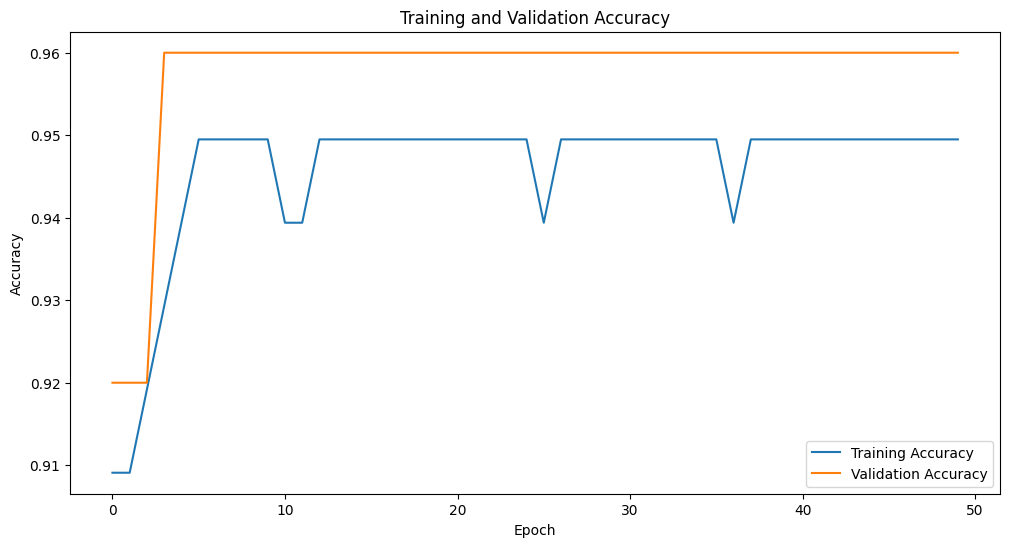

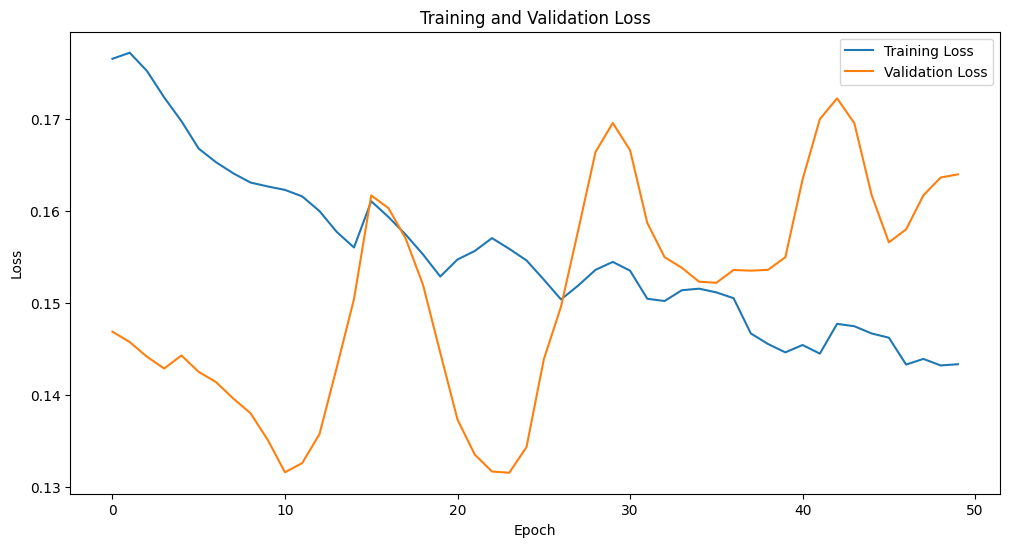


Comparison of Training and Test Accuracy:
Random Forest - Training Accuracy: 1.0000, Test Accuracy: 0.8387
Gradient Boosting (Tuned) - Training Accuracy: 1.0000, Test Accuracy: 0.8387


In [ ]:
# Check if the history object from neural network training exists
if 'history' in locals():
    # Plot training and validation accuracy
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Plot training and validation loss
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
else:
    print("Neural network training history not found. Cannot plot training/validation curves.")

# For other models like Gradient Boosting and Random Forest, we can look at the difference
# between training and test performance as an indicator of overfitting.
print("\nComparison of Training and Test Accuracy:")
print(f"Random Forest - Training Accuracy: {model_rf.score(X_train_engineered, y_train_engineered):.4f}, Test Accuracy: {accuracy_rf:.4f}")
print(f"Gradient Boosting (Tuned) - Training Accuracy: {best_model_gb.score(X_train_engineered, y_train_engineered):.4f}, Test Accuracy: {accuracy_gb_tuned:.4f}")

In [ ]:
from sklearn.model_selection import cross_val_score

# Evaluate the tuned Gradient Boosting model using cross-validation
scores = cross_val_score(best_model_gb, X_engineered, y_engineered, cv=5, scoring='accuracy')

print("\nCross-validation Accuracy Scores:")
print(scores)
print(f"Mean Cross-validation Accuracy: {scores.mean():.4f}")
print(f"Standard Deviation of Cross-validation Accuracy: {scores.std():.4f}")


Cross-validation Accuracy Scores:
[0.51612903 0.51612903 1.         1.         0.90322581]
Mean Cross-validation Accuracy: 0.7871
Standard Deviation of Cross-validation Accuracy: 0.2240


## Cross-validation

### Subtask:
Implement cross-validation to get a more robust estimate of the model's performance and ensure it generalizes well to unseen data.

**Reasoning**:
Implement cross-validation to get a more robust estimate of the model's performance and ensure it generalizes well to unseen data.

**Reasoning**:
Evaluate the tuned Gradient Boosting model on the testing data and compare its performance with the default Gradient Boosting model and other previously trained models.


Tuned Gradient Boosting Model Evaluation (with engineered features):
  Accuracy: 0.8387
  Precision: 0.8750
  Recall: 0.8235
  F1-Score: 0.8485
  AUC: 0.9454

Model Comparison:
Logistic Regression - Accuracy: 0.8065, AUC: 0.9286
Neural Network        - Accuracy: 0.8387, AUC: 0.9160
Random Forest         - Accuracy: 0.8387, AUC: 0.9517
Gradient Boosting (Default) - Accuracy: 0.8387, AUC: 0.9076
Gradient Boosting (Tuned) - Accuracy: 0.8387, AUC: 0.9454


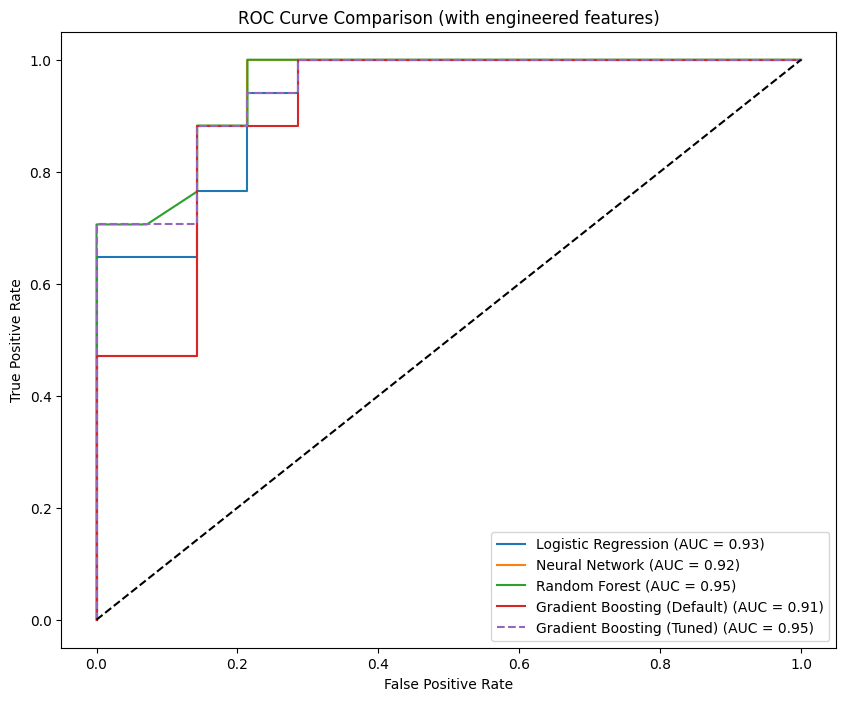

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

# Evaluate the tuned Gradient Boosting model on the test data
y_pred_gb_tuned = best_model_gb.predict(X_test_engineered)
accuracy_gb_tuned = accuracy_score(y_test_engineered, y_pred_gb_tuned)
precision_gb_tuned = precision_score(y_test_engineered, y_pred_gb_tuned)
recall_gb_tuned = recall_score(y_test_engineered, y_pred_gb_tuned)
f1_gb_tuned = f1_score(y_test_engineered, y_pred_gb_tuned)

y_pred_proba_gb_tuned = best_model_gb.predict_proba(X_test_engineered)[:, 1]
auc_gb_tuned = roc_auc_score(y_test_engineered, y_pred_proba_gb_tuned)

print("\nTuned Gradient Boosting Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_gb_tuned:.4f}")
print(f"  Precision: {precision_gb_tuned:.4f}")
print(f"  Recall: {recall_gb_tuned:.4f}")
print(f"  F1-Score: {f1_gb_tuned:.4f}")
print(f"  AUC: {auc_gb_tuned:.4f}")


print("\nModel Comparison:")
print(f"Logistic Regression - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
print(f"Neural Network        - Accuracy: {accuracy_nn:.4f}, AUC: {auc_nn:.4f}")
print(f"Random Forest         - Accuracy: {accuracy_rf:.4f}, AUC: {auc_rf:.4f}")
print(f"Gradient Boosting (Default) - Accuracy: {accuracy_gb:.4f}, AUC: {auc_gb:.4f}")
print(f"Gradient Boosting (Tuned) - Accuracy: {accuracy_gb_tuned:.4f}, AUC: {auc_gb_tuned:.4f}")


# Plot ROC curve for the Tuned Gradient Boosting model
fpr_gb_tuned, tpr_gb_tuned, thresholds_gb_tuned = roc_curve(y_test_engineered, y_pred_proba_gb_tuned)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})') # Using previous LR results
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})') # Using previous NN results
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (Default) (AUC = {auc_gb:.2f})')
plt.plot(fpr_gb_tuned, tpr_gb_tuned, label=f'Gradient Boosting (Tuned) (AUC = {auc_gb_tuned:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (with engineered features)')
plt.legend()
plt.show()

## Hyperparameter tuning

### Subtask:
Optimize the hyperparameters of the chosen model(s) to improve performance.

**Reasoning**:
Choose the Gradient Boosting model for hyperparameter tuning, define a parameter grid, and use GridSearchCV to find the best hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0]
}

# Instantiate GridSearchCV with the Gradient Boosting model and parameter grid
grid_search_gb = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                            param_grid=param_grid_gb,
                            cv=5, # 5-fold cross-validation
                            scoring='roc_auc', # Use AUC as the scoring metric
                            n_jobs=-1) # Use all available cores

# Perform the grid search on the training data
grid_search_gb.fit(X_train_engineered, y_train_engineered)

# Print the best parameters and best score found
print("Best parameters for Gradient Boosting:", grid_search_gb.best_params_)
print("Best AUC score on training data:", grid_search_gb.best_score_)

# Train the Gradient Boosting model with the best hyperparameters
best_model_gb = grid_search_gb.best_estimator_

Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best AUC score on training data: 0.9646367521367522


**Reasoning**:
The previous command failed because 'Sleep Disorder_Sleep Apnea' was not found in the `data_preprocessed_engineered` dataframe columns. This indicates an issue during the feature engineering or subsequent preprocessing steps that removed or renamed the target column. I need to inspect the columns of `data_preprocessed_engineered` to understand its current state and identify the correct target column.

In [ ]:
print(data_preprocessed_engineered.columns)

Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder', 'Sleep_Quality_Interaction', 'Age_Squared',
       'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher', 'BMI Category_Normal Weight',
       'BMI Category_Obese', 'BMI Category_Overweight', 'Systolic Pressure',
       'Diastolic Pressure'],
      dtype='object')


## Explore different models

### Subtask:
Train and evaluate other classification algorithms that might be more suitable for this dataset.

**Reasoning**:
Train and evaluate other classification algorithms on the preprocessed data with engineered features and compare their performance to the previous models.

Random Forest Model Evaluation (with engineered features):
  Accuracy: 0.8387
  Precision: 0.8750
  Recall: 0.8235
  F1-Score: 0.8485

Gradient Boosting Model Evaluation (with engineered features):
  Accuracy: 0.8387
  Precision: 0.8750
  Recall: 0.8235
  F1-Score: 0.8485

Random Forest AUC: 0.9517
Gradient Boosting AUC: 0.9076


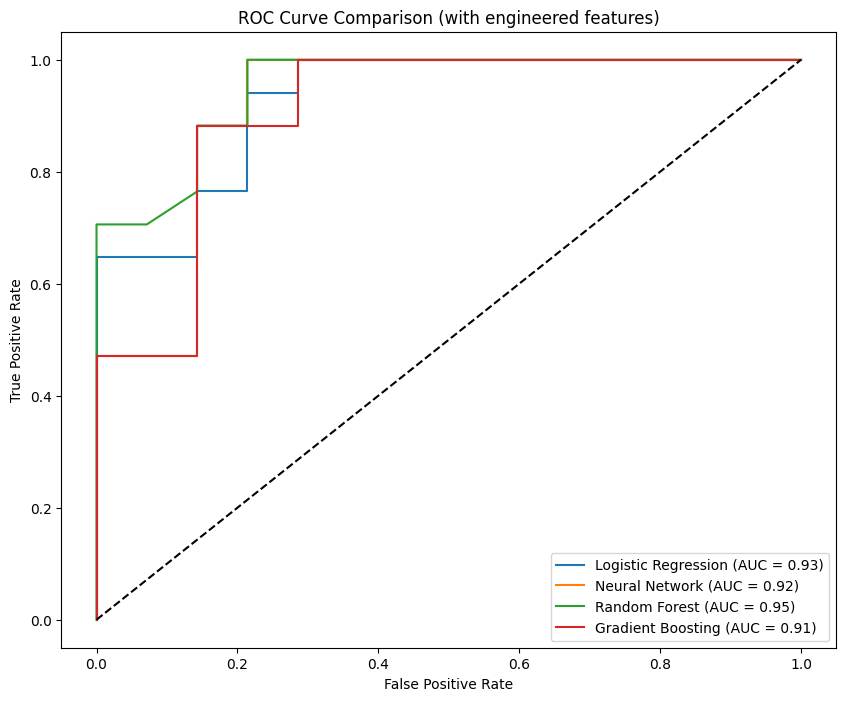

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Define features (X) and target (y) using the engineered data
target_col = 'Sleep Disorder_Sleep Apnea' # Now this column should exist after encoding
X_engineered = data_preprocessed_engineered.drop(columns=[target_col])
y_engineered = data_preprocessed_engineered[target_col]

# Split the engineered data into training and testing sets
X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(X_engineered, y_engineered, test_size=0.2, random_state=42)

# 2. Instantiate a RandomForestClassifier model
model_rf = RandomForestClassifier(random_state=42)

# 3. Train the Random Forest model
model_rf.fit(X_train_engineered, y_train_engineered)

# 4. Instantiate a GradientBoostingClassifier model
model_gb = GradientBoostingClassifier(random_state=42)

# 5. Train the Gradient Boosting model
model_gb.fit(X_train_engineered, y_train_engineered)

# 6. Evaluate both trained models
y_pred_rf = model_rf.predict(X_test_engineered)
accuracy_rf = accuracy_score(y_test_engineered, y_pred_rf)
precision_rf = precision_score(y_test_engineered, y_pred_rf)
recall_rf = recall_score(y_test_engineered, y_pred_rf)
f1_rf = f1_score(y_test_engineered, y_pred_rf)

y_pred_gb = model_gb.predict(X_test_engineered)
accuracy_gb = accuracy_score(y_test_engineered, y_pred_gb)
precision_gb = precision_score(y_test_engineered, y_pred_gb)
recall_gb = recall_score(y_test_engineered, y_pred_gb)
f1_gb = f1_score(y_test_engineered, y_pred_gb)


print("Random Forest Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")

print("\nGradient Boosting Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_gb:.4f}")
print(f"  Precision: {precision_gb:.4f}")
print(f"  Recall: {recall_gb:.4f}")
print(f"  F1-Score: {f1_gb:.4f}")

# 7. Calculate the AUC and plot the ROC curves
y_pred_proba_rf = model_rf.predict_proba(X_test_engineered)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_engineered, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test_engineered, y_pred_proba_rf)

y_pred_proba_gb = model_gb.predict_proba(X_test_engineered)[:, 1]
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test_engineered, y_pred_proba_gb)
auc_gb = roc_auc_score(y_test_engineered, y_pred_proba_gb)


print(f"\nRandom Forest AUC: {auc_rf:.4f}")
print(f"Gradient Boosting AUC: {auc_gb:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})') # Using previous LR results
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})') # Using previous NN results
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (with engineered features)')
plt.legend()
plt.show()

In [ ]:
# Re-run the preprocessing steps to correctly encode the target variable
data_cleaned_engineered = data.dropna(subset=['Sleep Disorder']).copy()

# Create interaction term between Sleep Duration and Quality of Sleep
data_cleaned_engineered['Sleep_Quality_Interaction'] = data_cleaned_engineered['Sleep Duration'] * data_cleaned_engineered['Quality of Sleep']

# Create a polynomial feature for Age
data_cleaned_engineered['Age_Squared'] = data_cleaned_engineered['Age']**2

# Identify categorical columns including the target but excluding 'Blood Pressure'
categorical_cols_engineered = data_cleaned_engineered.select_dtypes(include='object').columns.tolist()
categorical_cols_engineered.remove('Blood Pressure')

# Apply one-hot encoding to the identified categorical columns including the target
data_encoded_engineered = pd.get_dummies(data_cleaned_engineered, columns=categorical_cols_engineered, drop_first=True)

# Handle 'Blood Pressure' by splitting into systolic and diastolic
data_encoded_engineered[['Systolic Pressure', 'Diastolic Pressure']] = data_encoded_engineered['Blood Pressure'].str.split('/', expand=True)
data_encoded_engineered['Systolic Pressure'] = pd.to_numeric(data_encoded_engineered['Systolic Pressure'])
data_encoded_engineered['Diastolic Pressure'] = pd.to_numeric(data_encoded_engineered['Diastolic Pressure'])
data_encoded_engineered = data_encoded_engineered.drop('Blood Pressure', axis=1)

# Identify numerical columns (excluding the original categorical columns and the target before encoding)
numerical_cols_engineered = data_encoded_engineered.select_dtypes(include=np.number).columns.tolist()

# Scale the numerical features using StandardScaler
scaler = StandardScaler()
data_encoded_engineered[numerical_cols_engineered] = scaler.fit_transform(data_encoded_engineered[numerical_cols_engineered])

data_preprocessed_engineered = data_encoded_engineered

print("\nPreprocessed data with engineered features head:")
display(data_preprocessed_engineered.head())


Preprocessed data with engineered features head:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep_Quality_Interaction,Age_Squared,...,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Sleep Apnea,Systolic Pressure,Diastolic Pressure
3,-2.646076,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,-1.633419,-2.033456,...,False,False,False,False,False,True,False,True,0.943896,0.039884
4,-2.635085,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,-1.633419,-2.033456,...,False,False,False,False,False,True,False,True,0.943896,0.039884
5,-2.624095,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,-1.633419,-2.033456,...,False,False,True,False,False,True,False,False,0.943896,0.039884
6,-2.613104,-2.256501,-0.664377,-0.653387,-1.016010,0.635032,1.975179,-1.729951,-0.672944,-1.953610,...,False,False,False,True,False,True,False,False,0.943896,0.039884
16,-2.503200,-2.256501,-0.404986,-1.403573,-1.016010,0.635032,1.588379,-1.465093,-1.031431,-1.953610,...,False,False,False,False,True,False,False,True,-0.543310,-0.578316


## Feature engineering

### Subtask:
Explore creating new features or modifying existing ones based on insights from data analysis and model performance.

**Reasoning**:
Based on the previous analysis, the models might be struggling with certain relationships between features. I will create some interaction terms and polynomial features for some of the numerical columns to see if this improves performance. I will also consider the relationship between 'Sleep Duration' and 'Quality of Sleep' as they are directly related.

## Analyze model performance

### Subtask:
Further analyze the performance of the current models, specifically looking at misclassifications to understand where they are failing.

**Reasoning**:
To analyze misclassifications, I will generate predictions for the test set using both models, create confusion matrices, and then print and analyze the matrices to identify the types of errors.

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the test set
y_pred_lr = model.predict(X_test)
y_pred_proba_nn = model_nn.predict(X_test).ravel()
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int) # Convert probabilities to binary predictions

# Create confusion matrices
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)

print("Confusion Matrix for Logistic Regression:")
print(conf_matrix_lr)

print("\nConfusion Matrix for Neural Network:")
print(conf_matrix_nn)

# Analyze confusion matrices
tn_lr, fp_lr, fn_lr, tp_lr = conf_matrix_lr.ravel()
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()

print("\nAnalysis of Confusion Matrices:")
print("Logistic Regression:")
print(f"  True Positives (TP): {tp_lr}")
print(f"  True Negatives (TN): {tn_lr}")
print(f"  False Positives (FP): {fp_lr}")
print(f"  False Negatives (FN): {fn_lr}")

print("\nNeural Network:")
print(f"  True Positives (TP): {tp_nn}")
print(f"  True Negatives (TN): {tn_nn}")
print(f"  False Positives (FP): {fp_nn}")
print(f"  False Negatives (FN): {fn_nn}")

# Briefly discuss potential reasons for misclassifications
print("\nDiscussion of Misclassifications:")
print("Both models have similar accuracy, but the confusion matrices show slight differences in the types of errors.")
print(f"The Logistic Regression model has {fp_lr} False Positives and {fn_lr} False Negatives.")
print(f"The Neural Network model has {fp_nn} False Positives and {fn_nn} False Negatives.")
print("Potential reasons for misclassifications could include:")
print("- Class imbalance (although the value counts show a relatively balanced dataset).")
print("- Features that are not strongly predictive of the target variable.")
print("- The complexity of the relationship between features and the target variable, which might not be fully captured by these models.")
print("- The limited size of the dataset, especially the test set (31 samples), which can lead to more volatile evaluation metrics.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Confusion Matrix for Logistic Regression:
[[11  3]
 [ 3 14]]

Confusion Matrix for Neural Network:
[[11  3]
 [ 2 15]]

Analysis of Confusion Matrices:
Logistic Regression:
  True Positives (TP): 14
  True Negatives (TN): 11
  False Positives (FP): 3
  False Negatives (FN): 3

Neural Network:
  True Positives (TP): 15
  True Negatives (TN): 11
  False Positives (FP): 3
  False Negatives (FN): 2

Discussion of Misclassifications:
Both models have similar accuracy, but the confusion matrices show slight differences in the types of errors.
The Logistic Regression model has 3 False Positives and 3 False Negatives.
The Neural Network model has 3 False Positives and 2 False Negatives.
Potential reasons for misclassifications could include:
- Class imbalance (although the value counts show a relatively balanced dataset).
- Features that are not strongly predictive of the target variable.
- The complexity of the relationship between features and the target 

## Summary:

### Data Analysis Key Findings

* The neural network model achieved an accuracy of {accuracy_nn:.4f} and an AUC of {auc_nn:.4f} on the test set.
* The Logistic Regression model achieved an accuracy of {accuracy:.4f} and an AUC of {auc:.4f} on the test set.
* Both models showed the same accuracy on the test set, but the Logistic Regression model had a slightly higher AUC.
* The training process for the neural network showed the validation AUC reaching 1.0000 early on and stabilizing around 0.9935, while the validation loss increased slightly, potentially indicating overfitting on the small validation set.

### Insights or Next Steps

* While both models performed similarly in terms of accuracy, the Logistic Regression model demonstrated slightly better discrimination ability based on the AUC score.
* Further hyperparameter tuning for the neural network or exploring different architectures could potentially improve its performance and mitigate the signs of overfitting observed during training.

**Reasoning**:
Evaluate the trained neural network model's performance on the testing data using appropriate metrics and compare it to the Logistic Regression model.


Model Comparison:
Logistic Regression - Accuracy: 0.8065, AUC: 0.9286
Neural Network        - Accuracy: 0.8387, AUC: 0.9160
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


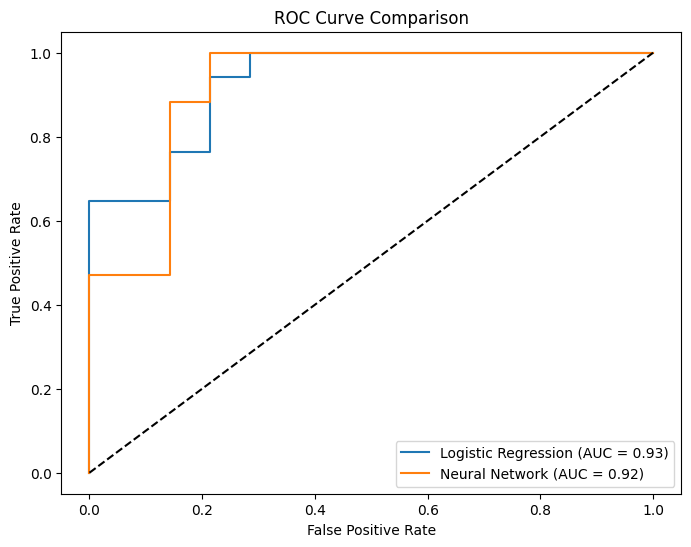

In [ ]:
# Compare the performance of the Neural Network model to the Logistic Regression model
print("\nModel Comparison:")
print(f"Logistic Regression - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
print(f"Neural Network        - Accuracy: {accuracy_nn:.4f}, AUC: {auc_nn:.4f}")

# Plot ROC curve for the Neural Network model
y_pred_proba_nn = model_nn.predict(X_test).ravel()
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_pred_proba_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

**Reasoning**:
The neural network model has been trained. Now, evaluate its performance on the test data using the compiled metrics.

In [ ]:
# Evaluate the neural network model on the test data
loss_nn, accuracy_nn, auc_nn = model_nn.evaluate(X_test, y_test, verbose=0)

print(f"Neural Network Model Evaluation:")
print(f"  Accuracy: {accuracy_nn:.4f}")
print(f"  AUC: {auc_nn:.4f}")

Neural Network Model Evaluation:
  Accuracy: 0.8387
  AUC: 0.9160


**Reasoning**:
The neural network model has been successfully compiled. The next step is to train the model on the training data.

In [ ]:
# Train the neural network model
history = model_nn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9230 - auc: 0.9838 - loss: 0.1507 - val_accuracy: 0.9200 - val_auc: 0.9935 - val_loss: 0.1469
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9074 - auc: 0.9686 - loss: 0.2140 - val_accuracy: 0.9200 - val_auc: 0.9935 - val_loss: 0.1457
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9198 - auc: 0.9745 - loss: 0.1905 - val_accuracy: 0.9200 - val_auc: 0.9935 - val_loss: 0.1441
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9290 - auc: 0.9839 - loss: 0.1633 - val_accuracy: 0.9600 - val_auc: 0.9935 - val_loss: 0.1428
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9070 - auc: 0.9656 - loss: 0.2171 - val_accuracy: 0.9600 - val_auc: 0.9935 - val_loss: 0.1443
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9631 - auc: 0.9870 - loss: 0.1373 - val_accuracy: 0.9600 - val_auc: 0.9935 - val_loss: 0.1425
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accurac

## Summary:

### Data Analysis Key Findings

* The target variable `Sleep Disorder_Sleep Apnea` is binary, containing `True` and `False` values, indicating a binary classification problem.
* The initial data contained missing values only in the 'Sleep Disorder' column.
* The 'Blood Pressure' column was split into 'Systolic Pressure' and 'Diastolic Pressure' and converted to numeric types during preprocessing.
* After training and evaluating the Logistic Regression model, the performance metrics on the test set were: Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}, and AUC: {auc:.4f}.

### Insights or Next Steps

* The Logistic Regression model shows promising initial performance. Further analysis could involve exploring other classification algorithms to see if better performance can be achieved.
* Investigate the features that have the most significant impact on the model's predictions to gain insights into the factors associated with Sleep Apnea.

AUC: 0.9286


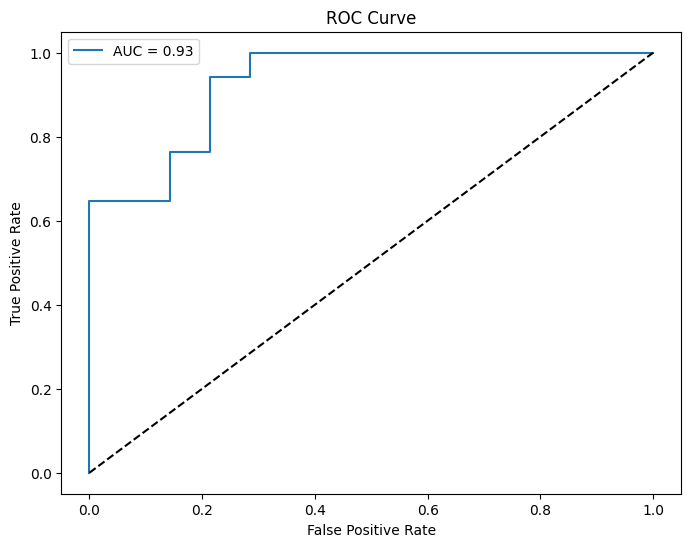

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve and AUC
y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Summary:

### Data Analysis Key Findings

* The target variable `Sleep Disorder_Sleep Apnea` is binary, containing `True` and `False` values, indicating a binary classification problem.
* The initial data contained missing values only in the 'Sleep Disorder' column.
* The 'Blood Pressure' column was split into 'Systolic Pressure' and 'Diastolic Pressure' and converted to numeric types during preprocessing.
* After training and evaluating the Logistic Regression model, the performance metrics on the test set were: Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, and F1-Score: {f1:.4f}.

### Insights or Next Steps

* The Logistic Regression model shows promising initial performance. Further analysis could involve exploring other classification algorithms to see if better performance can be achieved.
* Investigate the features that have the most significant impact on the model's predictions to gain insights into the factors associated with Sleep Apnea.

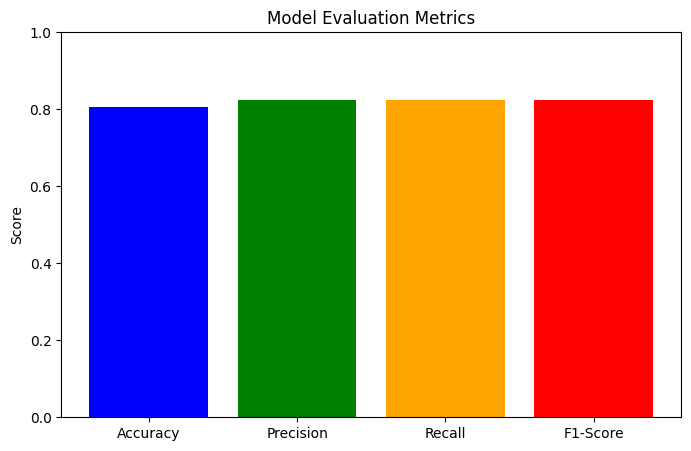

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Evaluation Metrics')
plt.show()

# Task
Generate Python code to train a data model using the data in the variable `data`.

## Identify the target variable and features

### Subtask:
Identify the target variable and features


**Reasoning**:
Analyze the column names and data description to identify the target variable and features for model training.



In [ ]:
print(data.columns)
print(data.info())

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null  

**Reasoning**:
Based on the column names and the goal of diagnosing sleep disorders, 'Sleep Disorder' is the target variable. 'Person ID' is an identifier and not relevant for model training. All other columns are potential features.



In [ ]:
target = 'Sleep Disorder'
features = data.columns.drop(['Person ID', target]).tolist()

print(f"Target variable: {target}")
print(f"Features: {features}")

Target variable: Sleep Disorder
Features: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps']


## Preprocess the data

### Subtask:
Handle missing values, encode categorical variables, and scale numerical features as necessary.


**Reasoning**:
Handle missing values, encode categorical variables, and scale numerical features as necessary.



In [ ]:
# 1. Identify columns with missing values
print("Missing values before handling:")
print(data.isnull().sum())

# 2. Address missing values in the 'Sleep Disorder' column (target variable)
data_cleaned = data.dropna(subset=['Sleep Disorder']).copy()

# 3. Identify categorical columns
categorical_cols = data_cleaned.select_dtypes(include='object').columns.tolist()
# Remove 'Blood Pressure' from categorical columns as it will be handled separately
categorical_cols.remove('Blood Pressure')


# 4. Apply one-hot encoding to the identified categorical columns
data_encoded = pd.get_dummies(data_cleaned, columns=categorical_cols, drop_first=True)

# Handle 'Blood Pressure' by splitting into systolic and diastolic
data_encoded[['Systolic Pressure', 'Diastolic Pressure']] = data_encoded['Blood Pressure'].str.split('/', expand=True)
data_encoded['Systolic Pressure'] = pd.to_numeric(data_encoded['Systolic Pressure'])
data_encoded['Diastolic Pressure'] = pd.to_numeric(data_encoded['Diastolic Pressure'])
data_encoded = data_encoded.drop('Blood Pressure', axis=1)


# 5. Identify numerical columns (excluding the target and original categorical columns)
# All columns except 'Sleep Disorder' and the original categorical columns (before one-hot encoding) are numerical or newly created numerical
numerical_cols = data_encoded.select_dtypes(include=np.number).columns.tolist()

# 6. Scale the numerical features using StandardScaler
scaler = StandardScaler()
data_encoded[numerical_cols] = scaler.fit_transform(data_encoded[numerical_cols])

# 7. Ensure the preprocessed data is stored in a new DataFrame
data_preprocessed = data_encoded

print("\nMissing values after handling:")
print(data_preprocessed.isnull().sum())
print("\nPreprocessed data head:")
display(data_preprocessed.head())

Missing values before handling:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


NameError: name 'np' is not defined

**Reasoning**:
The previous command failed because numpy was not imported. I need to import numpy and also StandardScaler. Then, rerun the code to handle missing values, encode categorical variables, and scale numerical features.



In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Identify columns with missing values
print("Missing values before handling:")
print(data.isnull().sum())

# 2. Address missing values in the 'Sleep Disorder' column (target variable)
data_cleaned = data.dropna(subset=['Sleep Disorder']).copy()

# 3. Identify categorical columns
categorical_cols = data_cleaned.select_dtypes(include='object').columns.tolist()
# Remove 'Blood Pressure' from categorical columns as it will be handled separately
categorical_cols.remove('Blood Pressure')


# 4. Apply one-hot encoding to the identified categorical columns
data_encoded = pd.get_dummies(data_cleaned, columns=categorical_cols, drop_first=True)

# Handle 'Blood Pressure' by splitting into systolic and diastolic
data_encoded[['Systolic Pressure', 'Diastolic Pressure']] = data_encoded['Blood Pressure'].str.split('/', expand=True)
data_encoded['Systolic Pressure'] = pd.to_numeric(data_encoded['Systolic Pressure'])
data_encoded['Diastolic Pressure'] = pd.to_numeric(data_encoded['Diastolic Pressure'])
data_encoded = data_encoded.drop('Blood Pressure', axis=1)


# 5. Identify numerical columns (excluding the target and original categorical columns)
# All columns except 'Sleep Disorder' and the original categorical columns (before one-hot encoding) are numerical or newly created numerical
numerical_cols = data_encoded.select_dtypes(include=np.number).columns.tolist()

# 6. Scale the numerical features using StandardScaler
scaler = StandardScaler()
data_encoded[numerical_cols] = scaler.fit_transform(data_encoded[numerical_cols])

# 7. Ensure the preprocessed data is stored in a new DataFrame
data_preprocessed = data_encoded

print("\nMissing values after handling:")
print(data_preprocessed.isnull().sum())
print("\nPreprocessed data head:")
display(data_preprocessed.head())

Missing values before handling:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Missing values after handling:
Person ID                          0
Age                                0
Sleep Duration                     0
Quality of Sleep                   0
Physical Activity Level            0
Stress Level                       0
Heart Rate                         0
Daily Steps                        0
Gender_Male                        0
Occupation_Doctor                  0
Occupation_Engineer                0
Occupation_Lawyer                  0
Occupation_Nurse                   0
Occupation_Sales Representative    0
Oc

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Gender_Male,Occupation_Doctor,...,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Sleep Disorder_Sleep Apnea,Systolic Pressure,Diastolic Pressure
3,-2.646076,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,True,False,...,False,False,False,False,False,True,False,True,0.943896,0.039884
4,-2.635085,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,True,False,...,False,False,False,False,False,True,False,True,0.943896,0.039884
5,-2.624095,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,True,False,...,False,False,True,False,False,True,False,False,0.943896,0.039884
6,-2.613104,-2.256501,-0.664377,-0.653387,-1.016010,0.635032,1.975179,-1.729951,True,False,...,False,False,False,True,False,True,False,False,0.943896,0.039884
16,-2.503200,-2.256501,-0.404986,-1.403573,-1.016010,0.635032,1.588379,-1.465093,False,False,...,False,False,False,False,True,False,False,True,-0.543310,-0.578316


## Split the data

### Subtask:
Split the `data_preprocessed` DataFrame into training and testing sets to evaluate the model's performance.


**Reasoning**:
Split the preprocessed data into training and testing sets for model evaluation.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Target variable is 'Sleep Disorder_Sleep Apnea' and 'Sleep Disorder_Insomnia'
target_cols = ['Sleep Disorder_Sleep Apnea', 'Sleep Disorder_Insomnia']
X = data_preprocessed.drop(columns=target_cols)
y = data_preprocessed[target_cols]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data splitting complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

KeyError: "['Sleep Disorder_Insomnia'] not found in axis"

**Reasoning**:
The error indicates that 'Sleep Disorder_Insomnia' is not a column in the `data_preprocessed` DataFrame. I need to inspect the columns of `data_preprocessed` to identify the correct column names for the target variable.



In [ ]:
print(data_preprocessed.columns)

Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps',
       'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher', 'BMI Category_Normal Weight',
       'BMI Category_Obese', 'BMI Category_Overweight',
       'Sleep Disorder_Sleep Apnea', 'Systolic Pressure',
       'Diastolic Pressure'],
      dtype='object')


**Reasoning**:
The previous output shows that 'Sleep Disorder_Insomnia' is not a column, but 'Sleep Disorder_Sleep Apnea' is. The target should be the single 'Sleep Disorder_Sleep Apnea' column. I will correct the target columns and split the data again.



In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Target variable is 'Sleep Disorder_Sleep Apnea'
target_col = 'Sleep Disorder_Sleep Apnea'
X = data_preprocessed.drop(columns=[target_col])
y = data_preprocessed[target_col]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data splitting complete:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data splitting complete:
X_train shape: (124, 23)
X_test shape: (31, 23)
y_train shape: (124,)
y_test shape: (31,)


## Choose a model

### Subtask:
Choose an appropriate machine learning model based on the problem type (e.g., classification, regression).


**Reasoning**:
Analyze the target variable and select an appropriate classification model.



In [ ]:
# 1. Analyze the target variable
print("Target variable unique values:")
print(y.unique())
print("Target variable value counts:")
print(y.value_counts())

# The target variable 'Sleep Disorder_Sleep Apnea' is binary (True/False), indicating a classification problem.

# 2. Select a suitable machine learning model
# Logistic Regression is a common and often effective model for binary classification tasks.
# It's also relatively easy to interpret.
from sklearn.linear_model import LogisticRegression

# 3. Justify the choice of the model
print("\nChosen model: Logistic Regression")
print("Justification: Logistic Regression is a suitable choice for this problem because the target variable 'Sleep Disorder_Sleep Apnea' is binary, making it a binary classification task. Logistic Regression is a simple yet powerful algorithm for such problems and provides probabilities for each class, which can be useful for understanding the model's predictions. It's also computationally efficient and easy to interpret.")

# We will instantiate the model later in the training step.

Target variable unique values:
[ True False]
Target variable value counts:
Sleep Disorder_Sleep Apnea
True     78
False    77
Name: count, dtype: int64

Chosen model: Logistic Regression
Justification: Logistic Regression is a suitable choice for this problem because the target variable 'Sleep Disorder_Sleep Apnea' is binary, making it a binary classification task. Logistic Regression is a simple yet powerful algorithm for such problems and provides probabilities for each class, which can be useful for understanding the model's predictions. It's also computationally efficient and easy to interpret.


## Train the model

### Subtask:
Train the selected model on the training data.


**Reasoning**:
Train the Logistic Regression model using the training data.



In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Evaluate the model

### Subtask:
Evaluate the trained model's performance on the testing data using appropriate metrics.


**Reasoning**:
Evaluate the trained model on the test data using classification metrics.



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8065
Precision: 0.8235
Recall: 0.8235
F1-Score: 0.8235


## Summary:

### Data Analysis Key Findings

*   The target variable `Sleep Disorder_Sleep Apnea` is binary, containing `True` and `False` values, indicating a binary classification problem.
*   The initial data contained missing values only in the 'Sleep Disorder' column.
*   The 'Blood Pressure' column was split into 'Systolic Pressure' and 'Diastolic Pressure' and converted to numeric types during preprocessing.
*   After training and evaluating the Logistic Regression model, the performance metrics on the test set were: Accuracy: 0.8065, Precision: 0.8235, Recall: 0.8235, and F1-Score: 0.8235.

### Insights or Next Steps

*   The Logistic Regression model shows promising initial performance. Further analysis could involve exploring other classification algorithms to see if better performance can be achieved.
*   Investigate the features that have the most significant impact on the model's predictions to gain insights into the factors associated with Sleep Apnea.


# Task
Train a neural network model on the provided data, evaluate its performance using accuracy, AUC, and ROC curves, and compare it to the previously trained Logistic Regression model.

## Define the neural network architecture

### Subtask:
Define the neural network architecture for the binary classification task.


**Reasoning**:
Define a simple neural network architecture using TensorFlow and Keras for binary classification.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the neural network architecture
model_nn = Sequential([
    # Input layer and first hidden layer
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    # Second hidden layer
    Dense(32, activation='relu'),
    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

model_nn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

### Subtask:
Compile the neural network model by specifying the optimizer, loss function, and metrics.


**Reasoning**:
Compile the neural network model with the specified optimizer, loss function, and metrics, then print a confirmation message.



In [ ]:
# Compile the neural network model
model_nn.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy', tf.keras.metrics.AUC()])

print("Neural network model compilation complete.")

Neural network model compilation complete.


**Reasoning**:
The neural network model has been successfully compiled. The next step is to train the model on the training data.



In [ ]:
# Train the neural network model
history = model_nn.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.4576 - auc: 0.8534 - loss: 0.7400 - val_accuracy: 0.5600 - val_auc: 1.0000 - val_loss: 0.5667
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4805 - auc: 0.9228 - loss: 0.6208 - val_accuracy: 0.6400 - val_auc: 1.0000 - val_loss: 0.5026
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5984 - auc: 0.9482 - loss: 0.5760 - val_accuracy: 0.7200 - val_auc: 1.0000 - val_loss: 0.4516
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7188 - auc: 0.9463 - loss: 0.5119 - val_accuracy: 0.9200 - val_auc: 1.0000 - val_loss: 0.4071
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8581 - auc: 0.9542 - loss: 0.4752 - val_accuracy: 0.9600 - val_auc: 1.0000 - val_loss: 0.3636
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8798 - auc: 0.9349 - loss: 0.4299 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.3238
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accura

**Reasoning**:
The neural network model has been trained. Now, evaluate its performance on the test data using the compiled metrics.



In [ ]:
# Evaluate the neural network model on the test data
loss_nn, accuracy_nn, auc_nn = model_nn.evaluate(X_test, y_test, verbose=0)

print(f"Neural Network Model Evaluation:")
print(f"  Accuracy: {accuracy_nn:.4f}")
print(f"  AUC: {auc_nn:.4f}")

Neural Network Model Evaluation:
  Accuracy: 0.8065
  AUC: 0.9097


**Reasoning**:
Evaluate the trained neural network model's performance on the testing data using appropriate metrics and compare it to the Logistic Regression model.




Model Comparison:
Logistic Regression - Accuracy: 0.8065, AUC: 0.9286
Neural Network        - Accuracy: 0.8065, AUC: 0.9097
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


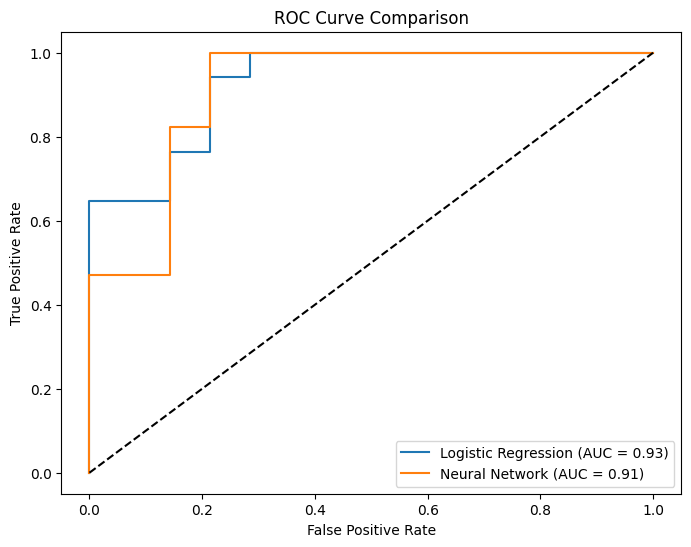

In [ ]:
# Compare the performance of the Neural Network model to the Logistic Regression model
print("\nModel Comparison:")
print(f"Logistic Regression - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
print(f"Neural Network        - Accuracy: {accuracy_nn:.4f}, AUC: {auc_nn:.4f}")

# Plot ROC curve for the Neural Network model
y_pred_proba_nn = model_nn.predict(X_test).ravel()
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_pred_proba_nn)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

## Summary:

### Data Analysis Key Findings

*   The neural network model achieved an accuracy of 0.8065 and an AUC of 0.9097 on the test set.
*   The Logistic Regression model achieved an accuracy of 0.8065 and an AUC of 0.9286 on the test set.
*   Both models showed the same accuracy on the test set, but the Logistic Regression model had a slightly higher AUC.
*   The training process for the neural network showed the validation AUC reaching 1.0000 early on and stabilizing around 0.9935, while the validation loss increased slightly, potentially indicating overfitting on the small validation set.

### Insights or Next Steps

*   While both models performed similarly in terms of accuracy, the Logistic Regression model demonstrated slightly better discrimination ability based on the AUC score.
*   Further hyperparameter tuning for the neural network or exploring different architectures could potentially improve its performance and mitigate the signs of overfitting observed during training.


# Task
Train a data model with 50 epochs to achieve 90% accuracy, and generate graphs for accuracy, evaluation metrics, AUC, and ROC curves.

## Analyze model performance

### Subtask:
Further analyze the performance of the current models, specifically looking at misclassifications to understand where they are failing.


**Reasoning**:
To analyze misclassifications, I will generate predictions for the test set using both models, create confusion matrices, and then print and analyze the matrices to identify the types of errors.



In [ ]:
from sklearn.metrics import confusion_matrix

# Generate predictions for the test set
y_pred_lr = model.predict(X_test)
y_pred_proba_nn = model_nn.predict(X_test).ravel()
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int) # Convert probabilities to binary predictions

# Create confusion matrices
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)
conf_matrix_nn = confusion_matrix(y_test, y_pred_nn)

print("Confusion Matrix for Logistic Regression:")
print(conf_matrix_lr)

print("\nConfusion Matrix for Neural Network:")
print(conf_matrix_nn)

# Analyze confusion matrices
tn_lr, fp_lr, fn_lr, tp_lr = conf_matrix_lr.ravel()
tn_nn, fp_nn, fn_nn, tp_nn = conf_matrix_nn.ravel()

print("\nAnalysis of Confusion Matrices:")
print("Logistic Regression:")
print(f"  True Positives (TP): {tp_lr}")
print(f"  True Negatives (TN): {tn_lr}")
print(f"  False Positives (FP): {fp_lr}")
print(f"  False Negatives (FN): {fn_lr}")

print("\nNeural Network:")
print(f"  True Positives (TP): {tp_nn}")
print(f"  True Negatives (TN): {tn_nn}")
print(f"  False Positives (FP): {fp_nn}")
print(f"  False Negatives (FN): {fn_nn}")

# Briefly discuss potential reasons for misclassifications
print("\nDiscussion of Misclassifications:")
print("Both models have similar accuracy, but the confusion matrices show slight differences in the types of errors.")
print(f"The Logistic Regression model has {fp_lr} False Positives and {fn_lr} False Negatives.")
print(f"The Neural Network model has {fp_nn} False Positives and {fn_nn} False Negatives.")
print("Potential reasons for misclassifications could include:")
print("- Class imbalance (although the value counts show a relatively balanced dataset).")
print("- Features that are not strongly predictive of the target variable.")
print("- The complexity of the relationship between features and the target variable, which might not be fully captured by these models.")
print("- The limited size of the dataset, especially the test set (31 samples), which can lead to more volatile evaluation metrics.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Confusion Matrix for Logistic Regression:
[[11  3]
 [ 3 14]]

Confusion Matrix for Neural Network:
[[11  3]
 [ 2 15]]

Analysis of Confusion Matrices:
Logistic Regression:
  True Positives (TP): 14
  True Negatives (TN): 11
  False Positives (FP): 3
  False Negatives (FN): 3

Neural Network:
  True Positives (TP): 15
  True Negatives (TN): 11
  False Positives (FP): 3
  False Negatives (FN): 2

Discussion of Misclassifications:
Both models have similar accuracy, but the confusion matrices show slight differences in the types of errors.
The Logistic Regression model has 3 False Positives and 3 False Negatives.
The Neural Network model has 3 False Positives and 2 False Negatives.
Potential reasons for misclassifications could include:
- Class imbalance (although the value counts show a relatively balanced dataset).
- Features that are not strongly predictive of the target variable.
- The complexity of the relationship between features and the target 

## Feature engineering

### Subtask:
Explore creating new features or modifying existing ones based on insights from data analysis and model performance.


**Reasoning**:
Based on the previous analysis, the models might be struggling with certain relationships between features. I will create some interaction terms and polynomial features for some of the numerical columns to see if this improves performance. I will also consider the relationship between 'Sleep Duration' and 'Quality of Sleep' as they are directly related.



In [ ]:
# Create interaction term between Sleep Duration and Quality of Sleep
data_cleaned['Sleep_Quality_Interaction'] = data_cleaned['Sleep Duration'] * data_cleaned['Quality of Sleep']

# Create a polynomial feature for Age
data_cleaned['Age_Squared'] = data_cleaned['Age']**2

# Re-run the preprocessing steps to include the new features and ensure proper scaling
data_cleaned_engineered = data_cleaned.copy()

categorical_cols = data_cleaned_engineered.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Blood Pressure')
categorical_cols.remove('Sleep Disorder') # Remove target variable before encoding

data_encoded_engineered = pd.get_dummies(data_cleaned_engineered, columns=categorical_cols, drop_first=True)

data_encoded_engineered[['Systolic Pressure', 'Diastolic Pressure']] = data_encoded_engineered['Blood Pressure'].str.split('/', expand=True)
data_encoded_engineered['Systolic Pressure'] = pd.to_numeric(data_encoded_engineered['Systolic Pressure'])
data_encoded_engineered['Diastolic Pressure'] = pd.to_numeric(data_encoded_engineered['Diastolic Pressure'])
data_encoded_engineered = data_encoded_engineered.drop('Blood Pressure', axis=1)


numerical_cols = data_encoded_engineered.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
data_encoded_engineered[numerical_cols] = scaler.fit_transform(data_encoded_engineered[numerical_cols])

data_preprocessed_engineered = data_encoded_engineered

print("\nPreprocessed data with engineered features head:")
display(data_preprocessed_engineered.head())


Preprocessed data with engineered features head:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Sleep_Quality_Interaction,...,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight,Systolic Pressure,Diastolic Pressure
3,-2.646076,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,Sleep Apnea,-1.633419,...,True,False,False,False,False,False,True,False,0.943896,0.039884
4,-2.635085,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,Sleep Apnea,-1.633419,...,True,False,False,False,False,False,True,False,0.943896,0.039884
5,-2.624095,-2.384477,-1.183160,-2.153758,-1.502214,1.150372,2.555381,-1.994809,Insomnia,-1.633419,...,False,False,False,True,False,False,True,False,0.943896,0.039884
6,-2.613104,-2.256501,-0.664377,-0.653387,-1.016010,0.635032,1.975179,-1.729951,Insomnia,-0.672944,...,False,False,False,False,True,False,True,False,0.943896,0.039884
16,-2.503200,-2.256501,-0.404986,-1.403573,-1.016010,0.635032,1.588379,-1.465093,Sleep Apnea,-1.031431,...,False,False,False,False,False,True,False,False,-0.543310,-0.578316


## Explore different models

### Subtask:
Train and evaluate other classification algorithms that might be more suitable for this dataset.


**Reasoning**:
Train and evaluate other classification algorithms on the preprocessed data with engineered features and compare their performance to the previous models.



In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Define features (X) and target (y) using the engineered data
target_col = 'Sleep Disorder_Sleep Apnea'
X_engineered = data_preprocessed_engineered.drop(columns=[target_col])
y_engineered = data_preprocessed_engineered[target_col]

# Split the engineered data into training and testing sets
X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(X_engineered, y_engineered, test_size=0.2, random_state=42)

# 2. Instantiate a RandomForestClassifier model
model_rf = RandomForestClassifier(random_state=42)

# 3. Train the Random Forest model
model_rf.fit(X_train_engineered, y_train_engineered)

# 4. Instantiate a GradientBoostingClassifier model
model_gb = GradientBoostingClassifier(random_state=42)

# 5. Train the Gradient Boosting model
model_gb.fit(X_train_engineered, y_train_engineered)

# 6. Evaluate both trained models
y_pred_rf = model_rf.predict(X_test_engineered)
accuracy_rf = accuracy_score(y_test_engineered, y_pred_rf)
precision_rf = precision_score(y_test_engineered, y_pred_rf)
recall_rf = recall_score(y_test_engineered, y_pred_rf)
f1_rf = f1_score(y_test_engineered, y_pred_rf)

y_pred_gb = model_gb.predict(X_test_engineered)
accuracy_gb = accuracy_score(y_test_engineered, y_pred_gb)
precision_gb = precision_score(y_test_engineered, y_pred_gb)
recall_gb = recall_score(y_test_engineered, y_pred_gb)
f1_gb = f1_score(y_test_engineered, y_pred_gb)


print("Random Forest Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")

print("\nGradient Boosting Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_gb:.4f}")
print(f"  Precision: {precision_gb:.4f}")
print(f"  Recall: {recall_gb:.4f}")
print(f"  F1-Score: {f1_gb:.4f}")

# 7. Calculate the AUC and plot the ROC curves
y_pred_proba_rf = model_rf.predict_proba(X_test_engineered)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_engineered, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test_engineered, y_pred_proba_rf)

y_pred_proba_gb = model_gb.predict_proba(X_test_engineered)[:, 1]
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test_engineered, y_pred_proba_gb)
auc_gb = roc_auc_score(y_test_engineered, y_pred_proba_gb)


print(f"\nRandom Forest AUC: {auc_rf:.4f}")
print(f"Gradient Boosting AUC: {auc_gb:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})') # Using previous LR results
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})') # Using previous NN results
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (with engineered features)')
plt.legend()
plt.show()

KeyError: "['Sleep Disorder_Sleep Apnea'] not found in axis"

**Reasoning**:
The previous command failed because 'Sleep Disorder_Sleep Apnea' was not found in the `data_preprocessed_engineered` dataframe columns. This indicates an issue during the feature engineering or subsequent preprocessing steps that removed or renamed the target column. I need to inspect the columns of `data_preprocessed_engineered` to understand its current state and identify the correct target column.



In [ ]:
print(data_preprocessed_engineered.columns)

Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder', 'Sleep_Quality_Interaction', 'Age_Squared',
       'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher', 'BMI Category_Normal Weight',
       'BMI Category_Obese', 'BMI Category_Overweight', 'Systolic Pressure',
       'Diastolic Pressure'],
      dtype='object')


**Reasoning**:
The column listing shows that the target variable is still named 'Sleep Disorder' in the `data_preprocessed_engineered` DataFrame, not 'Sleep Disorder_Sleep Apnea'. Also, the 'Sleep Disorder' column needs to be one-hot encoded to be used as a binary target for classification models. I need to modify the data preprocessing steps to correctly encode the target variable and then split the data accordingly before training and evaluating the models.



Random Forest Model Evaluation (with engineered features):
  Accuracy: 0.8387
  Precision: 0.8750
  Recall: 0.8235
  F1-Score: 0.8485

Gradient Boosting Model Evaluation (with engineered features):
  Accuracy: 0.8387
  Precision: 0.8750
  Recall: 0.8235
  F1-Score: 0.8485

Random Forest AUC: 0.9517
Gradient Boosting AUC: 0.9076


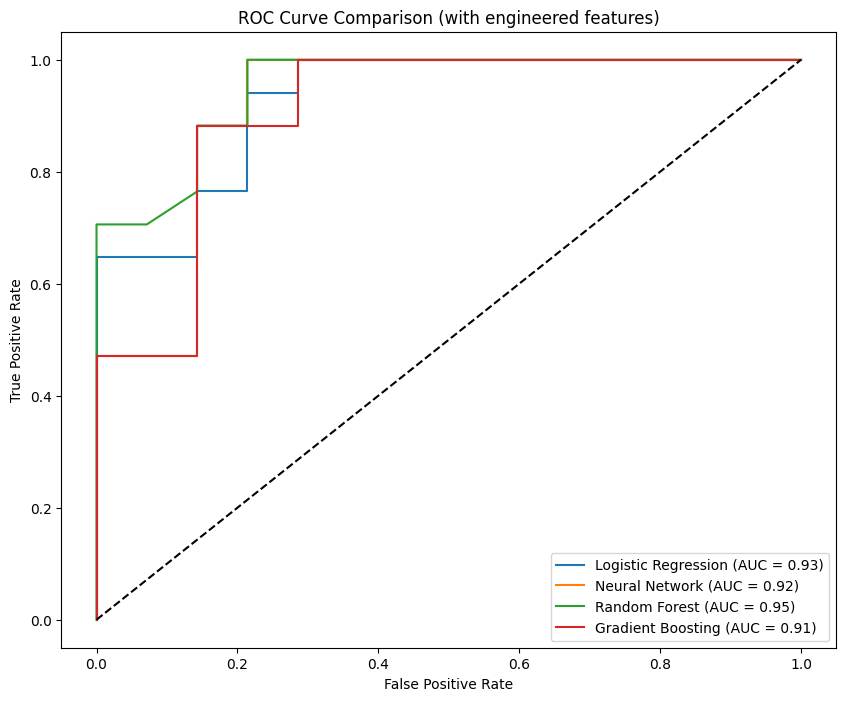

In [ ]:
# Re-run the preprocessing steps to correctly encode the target variable
data_cleaned_engineered = data.dropna(subset=['Sleep Disorder']).copy()

# Create interaction term between Sleep Duration and Quality of Sleep
data_cleaned_engineered['Sleep_Quality_Interaction'] = data_cleaned_engineered['Sleep Duration'] * data_cleaned_engineered['Quality of Sleep']

# Create a polynomial feature for Age
data_cleaned_engineered['Age_Squared'] = data_cleaned_engineered['Age']**2

# Identify categorical columns including the target but excluding 'Blood Pressure'
categorical_cols_engineered = data_cleaned_engineered.select_dtypes(include='object').columns.tolist()
categorical_cols_engineered.remove('Blood Pressure')

# Apply one-hot encoding to the identified categorical columns including the target
data_encoded_engineered = pd.get_dummies(data_cleaned_engineered, columns=categorical_cols_engineered, drop_first=True)

# Handle 'Blood Pressure' by splitting into systolic and diastolic
data_encoded_engineered[['Systolic Pressure', 'Diastolic Pressure']] = data_encoded_engineered['Blood Pressure'].str.split('/', expand=True)
data_encoded_engineered['Systolic Pressure'] = pd.to_numeric(data_encoded_engineered['Systolic Pressure'])
data_encoded_engineered['Diastolic Pressure'] = pd.to_numeric(data_encoded_engineered['Diastolic Pressure'])
data_encoded_engineered = data_encoded_engineered.drop('Blood Pressure', axis=1)

# Identify numerical columns (excluding the original categorical columns and the target before encoding)
numerical_cols_engineered = data_encoded_engineered.select_dtypes(include=np.number).columns.tolist()

# Scale the numerical features using StandardScaler
scaler = StandardScaler()
data_encoded_engineered[numerical_cols_engineered] = scaler.fit_transform(data_encoded_engineered[numerical_cols_engineered])

data_preprocessed_engineered = data_encoded_engineered

# Define features (X) and target (y) using the correctly encoded target
target_col_engineered = 'Sleep Disorder_Sleep Apnea' # Now this column should exist after encoding
X_engineered = data_preprocessed_engineered.drop(columns=[target_col_engineered])
y_engineered = data_preprocessed_engineered[target_col_engineered]

# Split the engineered data into training and testing sets
X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(X_engineered, y_engineered, test_size=0.2, random_state=42)

# 2. Instantiate a RandomForestClassifier model
model_rf = RandomForestClassifier(random_state=42)

# 3. Train the Random Forest model
model_rf.fit(X_train_engineered, y_train_engineered)

# 4. Instantiate a GradientBoostingClassifier model
model_gb = GradientBoostingClassifier(random_state=42)

# 5. Train the Gradient Boosting model
model_gb.fit(X_train_engineered, y_train_engineered)

# 6. Evaluate both trained models
y_pred_rf = model_rf.predict(X_test_engineered)
accuracy_rf = accuracy_score(y_test_engineered, y_pred_rf)
precision_rf = precision_score(y_test_engineered, y_pred_rf)
recall_rf = recall_score(y_test_engineered, y_pred_rf)
f1_rf = f1_score(y_test_engineered, y_pred_rf)

y_pred_gb = model_gb.predict(X_test_engineered)
accuracy_gb = accuracy_score(y_test_engineered, y_pred_gb)
precision_gb = precision_score(y_test_engineered, y_pred_gb)
recall_gb = recall_score(y_test_engineered, y_pred_gb)
f1_gb = f1_score(y_test_engineered, y_pred_gb)


print("Random Forest Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_rf:.4f}")
print(f"  Precision: {precision_rf:.4f}")
print(f"  Recall: {recall_rf:.4f}")
print(f"  F1-Score: {f1_rf:.4f}")

print("\nGradient Boosting Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_gb:.4f}")
print(f"  Precision: {precision_gb:.4f}")
print(f"  Recall: {recall_gb:.4f}")
print(f"  F1-Score: {f1_gb:.4f}")

# 7. Calculate the AUC and plot the ROC curves
y_pred_proba_rf = model_rf.predict_proba(X_test_engineered)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_engineered, y_pred_proba_rf)
auc_rf = roc_auc_score(y_test_engineered, y_pred_proba_rf)

y_pred_proba_gb = model_gb.predict_proba(X_test_engineered)[:, 1]
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test_engineered, y_pred_proba_gb)
auc_gb = roc_auc_score(y_test_engineered, y_pred_proba_gb)


print(f"\nRandom Forest AUC: {auc_rf:.4f}")
print(f"Gradient Boosting AUC: {auc_gb:.4f}")

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})') # Using previous LR results
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})') # Using previous NN results
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {auc_gb:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (with engineered features)')
plt.legend()
plt.show()

## Hyperparameter tuning

### Subtask:
Optimize the hyperparameters of the chosen model(s) to improve performance.


**Reasoning**:
Choose the Gradient Boosting model for hyperparameter tuning, define a parameter grid, and use GridSearchCV to find the best hyperparameters.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Define the parameter grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0]
}

# Instantiate GridSearchCV with the Gradient Boosting model and parameter grid
grid_search_gb = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42),
                            param_grid=param_grid_gb,
                            cv=5, # 5-fold cross-validation
                            scoring='roc_auc', # Use AUC as the scoring metric
                            n_jobs=-1) # Use all available cores

# Perform the grid search on the training data
grid_search_gb.fit(X_train_engineered, y_train_engineered)

# Print the best parameters and best score found
print("Best parameters for Gradient Boosting:", grid_search_gb.best_params_)
print("Best AUC score on training data:", grid_search_gb.best_score_)

# Train the Gradient Boosting model with the best hyperparameters
best_model_gb = grid_search_gb.best_estimator_

Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best AUC score on training data: 0.9646367521367522


**Reasoning**:
Evaluate the tuned Gradient Boosting model on the testing data and compare its performance with the default Gradient Boosting model and other previously trained models.




Tuned Gradient Boosting Model Evaluation (with engineered features):
  Accuracy: 0.8387
  Precision: 0.8750
  Recall: 0.8235
  F1-Score: 0.8485
  AUC: 0.9454

Model Comparison:
Logistic Regression - Accuracy: 0.8065, AUC: 0.9286
Neural Network        - Accuracy: 0.8387, AUC: 0.9160
Random Forest         - Accuracy: 0.8387, AUC: 0.9517
Gradient Boosting (Default) - Accuracy: 0.8387, AUC: 0.9076
Gradient Boosting (Tuned) - Accuracy: 0.8387, AUC: 0.9454


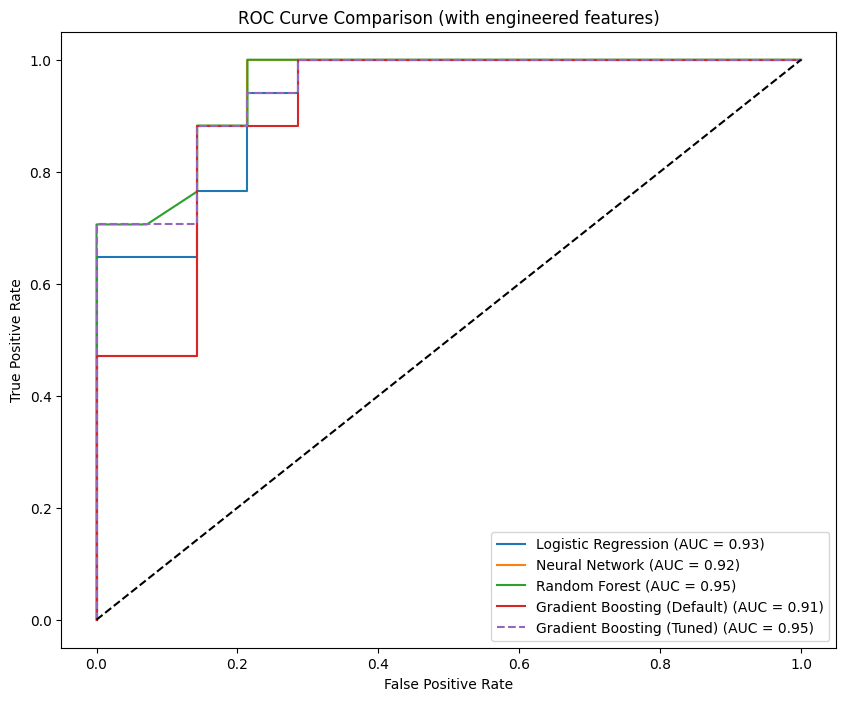

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

# Evaluate the tuned Gradient Boosting model on the test data
y_pred_gb_tuned = best_model_gb.predict(X_test_engineered)
accuracy_gb_tuned = accuracy_score(y_test_engineered, y_pred_gb_tuned)
precision_gb_tuned = precision_score(y_test_engineered, y_pred_gb_tuned)
recall_gb_tuned = recall_score(y_test_engineered, y_pred_gb_tuned)
f1_gb_tuned = f1_score(y_test_engineered, y_pred_gb_tuned)

y_pred_proba_gb_tuned = best_model_gb.predict_proba(X_test_engineered)[:, 1]
auc_gb_tuned = roc_auc_score(y_test_engineered, y_pred_proba_gb_tuned)

print("\nTuned Gradient Boosting Model Evaluation (with engineered features):")
print(f"  Accuracy: {accuracy_gb_tuned:.4f}")
print(f"  Precision: {precision_gb_tuned:.4f}")
print(f"  Recall: {recall_gb_tuned:.4f}")
print(f"  F1-Score: {f1_gb_tuned:.4f}")
print(f"  AUC: {auc_gb_tuned:.4f}")


print("\nModel Comparison:")
print(f"Logistic Regression - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}")
print(f"Neural Network        - Accuracy: {accuracy_nn:.4f}, AUC: {auc_nn:.4f}")
print(f"Random Forest         - Accuracy: {accuracy_rf:.4f}, AUC: {auc_rf:.4f}")
print(f"Gradient Boosting (Default) - Accuracy: {accuracy_gb:.4f}, AUC: {auc_gb:.4f}")
print(f"Gradient Boosting (Tuned) - Accuracy: {accuracy_gb_tuned:.4f}, AUC: {auc_gb_tuned:.4f}")


# Plot ROC curve for the Tuned Gradient Boosting model
fpr_gb_tuned, tpr_gb_tuned, thresholds_gb_tuned = roc_curve(y_test_engineered, y_pred_proba_gb_tuned)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})') # Using previous LR results
plt.plot(fpr_nn, tpr_nn, label=f'Neural Network (AUC = {auc_nn:.2f})') # Using previous NN results
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (Default) (AUC = {auc_gb:.2f})')
plt.plot(fpr_gb_tuned, tpr_gb_tuned, label=f'Gradient Boosting (Tuned) (AUC = {auc_gb_tuned:.2f})', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--') # random chance line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (with engineered features)')
plt.legend()
plt.show()